# Robustness to noise

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs
import h5py
import codecs

import EIANN.utils as ut
import EIANN.plot as pt

from EIANN.generate_figures import *

pt.update_plot_defaults()
root_dir = ut.get_project_root()

%load_ext autoreload
%autoreload 2

/Users/ag1880/github-repos/Milstein-Lab/EIANN/EIANN/utils/representation_analysis.py:8: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [3]:
figure_name = "Noise sensitivity"
model_list = ["vanBP", "bpDale_learned", "bpDale_fixed", "HebbWN_topsup", "bpLike_WT_hebbdend", "BTSP_WT_hebbdend"]
model_dict_all = load_model_dict()
generate_hdf5_all_seeds(model_list, model_dict_all, recompute=None)

Generating plots for Backprop (ANN)
Generating plots for Backprop (EIANN)
Generating plots for Backprop (EIANN)
Generating plots for Hebb (EIANN)
Generating plots for Dend. Target Prop.
Generating plots for Symmetric B=W (BTSP)


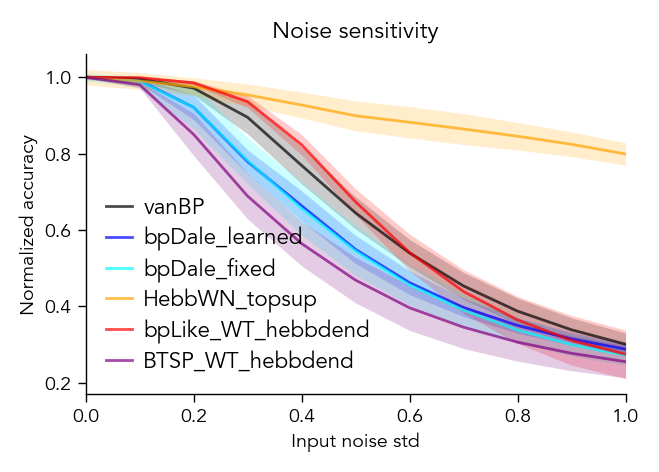

In [4]:
fig = plt.figure(figsize=(3, 2))
axes = gs.GridSpec(nrows=1, ncols=1, figure=fig,                    
                    left=0.05,right=0.95,
                    top=0.95, bottom=0.1)

ax = fig.add_subplot(axes[0, 0])
colors = {"vanBP": 'k',
        "bpDale_learned": 'blue',
        "bpDale_fixed": 'cyan',
        "HebbWN_topsup": 'orange',
        "bpLike_WT_hebbdend": 'red',
        "BTSP_WT_hebbdend": 'purple',
        "bpLike_TCWN_hebbdend": 'magenta'}

for model_key in model_list:
    model_dict = model_dict_all[model_key]
    network_name = model_dict['config'].split('.')[0]
    hdf5_path = root_dir + f"/EIANN/data/model_hdf5_plot_data/plot_data_{network_name}.h5"
    with h5py.File(hdf5_path, 'r') as f:
        data_dict = f[network_name]
        print(f"Generating plots for {model_dict['label']}")

        accuracy_list = []
        for seed in model_dict['seeds']:
            if "noise_sensitivity" not in data_dict[seed]:
                print(f"  No noise sensitivity data for seed {seed}, skipping...")
                continue

            noise_stds, noise_accuracy = data_dict[seed]['noise_sensitivity']
            accuracy_list.append(noise_accuracy)

        accuracy_array = np.array(accuracy_list)
        mean_accuracy = np.mean(accuracy_array, axis=0)
        mean_accuracy_norm = mean_accuracy / np.max(mean_accuracy)
        std_accuracy_norm = np.std(accuracy_array, axis=0) / np.max(mean_accuracy)
        ax.plot(noise_stds, mean_accuracy_norm, label=model_key, linewidth=1, color=colors[model_key], alpha=0.7)
        ax.fill_between(noise_stds, mean_accuracy_norm - std_accuracy_norm, mean_accuracy_norm + std_accuracy_norm, alpha=0.2, color=colors[model_key], linewidth=0.) 

        # std_accuracy = np.std(accuracy_array, axis=0)
        # ax.plot(noise_stds, mean_accuracy, label=model_dict['label'], linewidth=1)
        # ax.fill_between(noise_stds, mean_accuracy - std_accuracy, mean_accuracy + std_accuracy, alpha=0.1, color=colors[model_key])

ax.set_xlabel("Input noise std")
# ax.set_ylabel("Test accuracy (%)")
ax.set_ylabel("Normalized accuracy")
ax.set_title("Noise sensitivity")
ax.set_xlim([0, 1])
# ax.set_ylim([0, 100])
ax.legend(frameon=False, fontsize=8, loc='lower left')
plt.show(block=False)

# fig.savefig(f"figures/{figure_name}.svg", dpi=300)
# fig.savefig(f"figures/{figure_name}.png", dpi=300)